# 🎬 MovieLens Collaborative Filtering — SVD-Based Recommendation System
**Dataset:** MovieLens 100K | **Target:** Predict unseen movie ratings & generate Top-N recommendations

## 1. Import Required Libraries

In [1]:
# Install surprise if not present
# !pip install scikit-surprise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# Surprise library for model-based CF
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import cross_validate, train_test_split as surprise_split

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2. Load the MovieLens Dataset

In [2]:
# ── Load ratings ──────────────────────────────────────────────────────────────
df = pd.read_csv(
    r'..\data\u.data',
    sep='\t',
    names=['user_id', 'item_id', 'rating', 'timestamp']
)

# ── Load movie titles (optional, enriches recommendations) ────────────────────
try:
    movies = pd.read_csv(
        r'..\data\u.item',
        sep='|', encoding='latin-1',
        usecols=[0, 1],
        names=['item_id', 'title']
    )
    df = df.merge(movies, on='item_id', how='left')
    HAS_TITLES = True
    print('✅ Movie titles loaded')
except FileNotFoundError:
    HAS_TITLES = False
    df['title'] = 'Movie_' + df['item_id'].astype(str)
    print('⚠️  u.item not found — using generic titles')

print(f'Dataset shape : {df.shape}')
print(f'Users         : {df.user_id.nunique()}')
print(f'Items         : {df.item_id.nunique()}')
print(f'Rating range  : {df.rating.min()} – {df.rating.max()}')
df.head()

✅ Movie titles loaded
Dataset shape : (100000, 5)
Users         : 943
Items         : 1682
Rating range  : 1 – 5


,user_id,item_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


## 3. Data Preprocessing

── Missing values ──────────────────────────
user_id      0
item_id      0
rating       0
timestamp    0
title        0
dtype: int64

── Rating distribution ─────────────────────
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


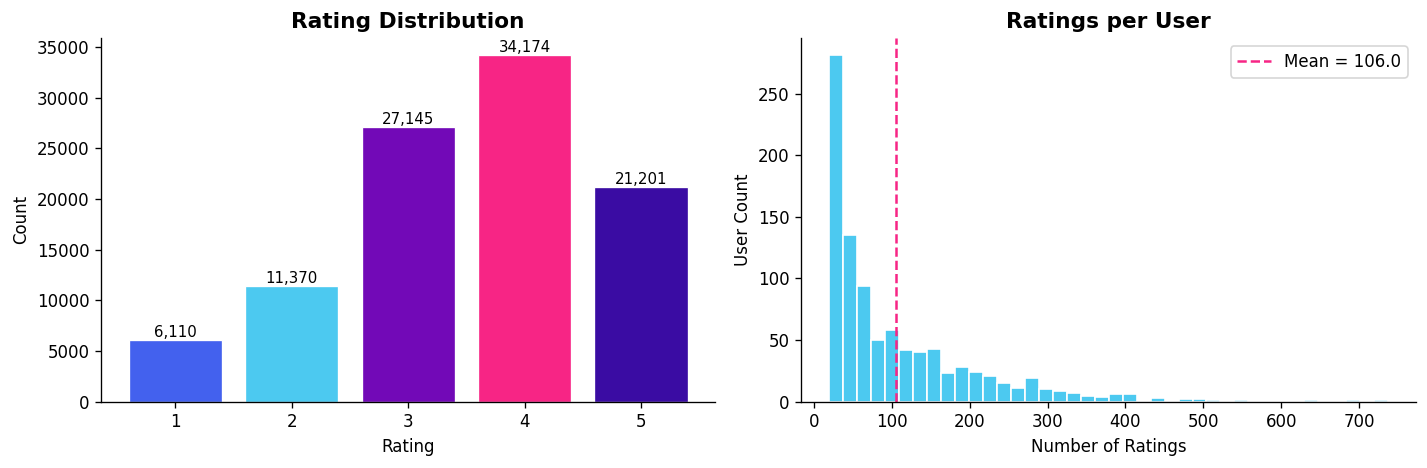


Train size: 80,000  |  Test size: 20,000


In [3]:
print('── Missing values ──────────────────────────')
print(df.isnull().sum())

print('\n── Rating distribution ─────────────────────')
print(df['rating'].value_counts().sort_index())

# ── Visualise rating distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rating histogram
ax = axes[0]
counts = df['rating'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values,
              color=['#4361ee','#4cc9f0','#7209b7','#f72585','#3a0ca3'],
              edgecolor='white', linewidth=0.8)
ax.set_title('Rating Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Count')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9)

# Ratings per user distribution
ax2 = axes[1]
ratings_per_user = df.groupby('user_id')['rating'].count()
ax2.hist(ratings_per_user, bins=40, color='#4cc9f0', edgecolor='white')
ax2.set_title('Ratings per User', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Ratings'); ax2.set_ylabel('User Count')
ax2.axvline(ratings_per_user.mean(), color='#f72585', linestyle='--',
            label=f'Mean = {ratings_per_user.mean():.1f}')
ax2.legend()

plt.tight_layout()
plt.savefig('rating_distribution.png', bbox_inches='tight')
plt.show()

# ── Train / Test split ────────────────────────────────────────────────────────
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f'\nTrain size: {len(train_df):,}  |  Test size: {len(test_df):,}')

## 4. Create User-Item Interaction Matrix

In [4]:
# Build the full user-item matrix (fill missing with 0)
user_item_matrix = df.pivot_table(
    index='user_id', columns='item_id', values='rating'
).fillna(0)

print(f'Matrix shape : {user_item_matrix.shape}')
sparsity = 1 - (df.shape[0] / (user_item_matrix.shape[0] * user_item_matrix.shape[1]))
print(f'Sparsity     : {sparsity*100:.2f}%')

R = user_item_matrix.values          # numpy array (943 × 1682)
user_ids  = user_item_matrix.index
item_ids  = user_item_matrix.columns
print('\nUser-Item matrix (first 5×8):')
pd.DataFrame(R[:5, :8], index=user_ids[:5], columns=item_ids[:8])

Matrix shape : (943, 1682)
Sparsity     : 93.70%

User-Item matrix (first 5×8):


item_id,1,2,3,4,5,6,7,8
user_id,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Normalise the Matrix — Mean Centering

In [5]:
# Compute mean rating per user (ignoring zeros / missing)
user_ratings_mean = np.true_divide(
    R.sum(axis=1),
    (R != 0).sum(axis=1)
)
user_ratings_mean = np.nan_to_num(user_ratings_mean)   # handle zero-row edge case

# Subtract user mean only from observed (non-zero) entries
R_demeaned = R.copy().astype(float)
for i in range(R.shape[0]):
    mask = R[i] != 0
    R_demeaned[i, mask] -= user_ratings_mean[i]

print('Mean-centered matrix (sample):')
print(np.round(R_demeaned[:3, :6], 3))
print(f'\nUser mean ratings — min: {user_ratings_mean.min():.2f}, '
      f'max: {user_ratings_mean.max():.2f}, '
      f'mean: {user_ratings_mean.mean():.2f}')

Mean-centered matrix (sample):
[[ 1.39 -0.61  0.39 -0.61 -0.61  1.39]
 [ 0.29  0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.  ]]

User mean ratings — min: 1.49, max: 4.87, mean: 3.59


## 6 & 7. SVD Decomposition + Dimension Reduction (select k latent factors)

SVD shapes for k=50:
  U     : (943, 50)   (users × latent factors)
  Σ     : (50, 50)
  Vt    : (50, 1682)   (latent factors × items)


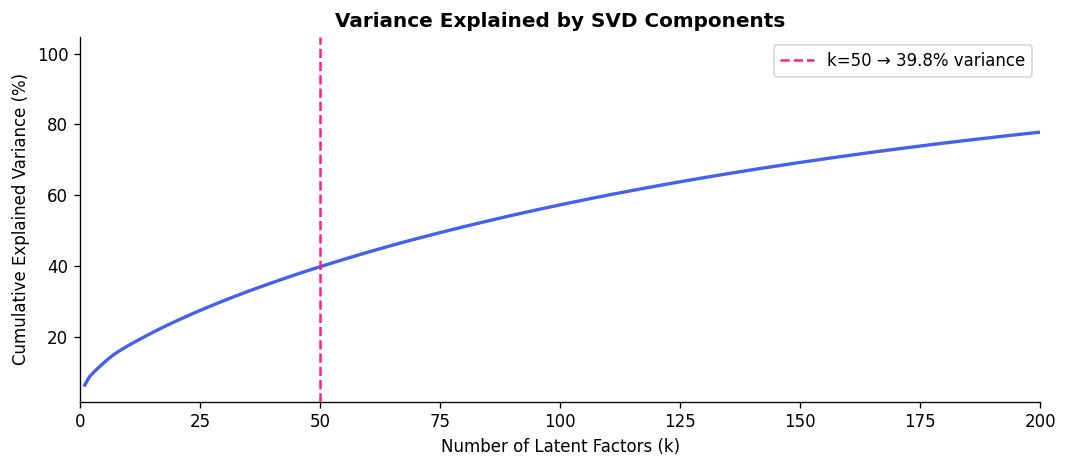

In [6]:
# scipy.sparse.linalg.svds returns k largest singular values
# R_demeaned ≈ U · Σ · Vt

K = 50   # number of latent factors (tunable)

U, sigma, Vt = svds(R_demeaned, k=K)
sigma_diag   = np.diag(sigma)

print(f'SVD shapes for k={K}:')
print(f'  U     : {U.shape}   (users × latent factors)')
print(f'  Σ     : {sigma_diag.shape}')
print(f'  Vt    : {Vt.shape}   (latent factors × items)')

# Variance explained
U_full, sigma_full, Vt_full = np.linalg.svd(R_demeaned, full_matrices=False)
explained_var = np.cumsum(sigma_full**2) / np.sum(sigma_full**2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(sigma_full)+1), explained_var*100, color='#4361ee', lw=2)
ax.axvline(K, color='#f72585', linestyle='--', label=f'k={K} → {explained_var[K-1]*100:.1f}% variance')
ax.set_xlabel('Number of Latent Factors (k)')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Variance Explained by SVD Components', fontweight='bold')
ax.legend(); ax.set_xlim(0, 200)
plt.tight_layout()
plt.savefig('svd_variance.png', bbox_inches='tight')
plt.show()

## 8. Reconstruct the Matrix

In [7]:
# Reconstruct: R̂ = U · Σ · Vt  (still mean-centered)
R_hat_centered = np.dot(np.dot(U, sigma_diag), Vt)

# Add back user means to get actual rating scale
R_hat = R_hat_centered + user_ratings_mean.reshape(-1, 1)

# Clip to valid rating range [1, 5]
R_hat = np.clip(R_hat, 1, 5)

# Wrap in DataFrame with same index/columns
predictions_df = pd.DataFrame(R_hat, index=user_ids, columns=item_ids)

print('Reconstructed matrix (first 5×5):')
predictions_df.iloc[:5, :5].round(2)

Reconstructed matrix (first 5×5):


item_id,1,2,3,4,5
user_id,,,,,
1,5.00,3.59,4.16,3.24,3.20
2,3.77,3.63,3.60,3.75,3.68
3,2.86,2.74,2.95,2.76,2.71
4,4.45,4.38,4.30,4.20,4.34
5,5.00,2.59,2.30,2.63,2.87


## 9. Predict Missing Ratings & Evaluate

k = 50
RMSE : 0.7197
MAE  : 0.5511


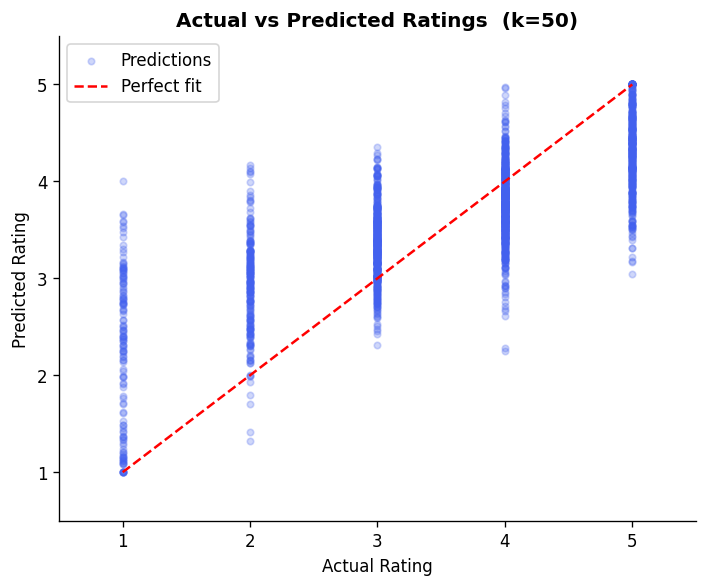

,user_id,item_id,rating,predicted_rating
75721,877,381,4,3.87
80184,815,602,3,3.85
19864,94,431,4,3.78
76699,416,875,2,2.53
92991,500,182,2,2.86
76434,259,1074,3,3.81
84004,598,286,5,4.65
80917,886,496,4,3.85
60767,837,15,3,3.40
50074,521,184,4,3.31


In [8]:
# ── Extract predictions for test set ──────────────────────────────────────────
def get_predicted_rating(row):
    uid = row['user_id']
    iid = row['item_id']
    if uid in predictions_df.index and iid in predictions_df.columns:
        return predictions_df.loc[uid, iid]
    return np.nan

test_df = test_df.copy()
test_df['predicted_rating'] = test_df.apply(get_predicted_rating, axis=1)
test_df.dropna(subset=['predicted_rating'], inplace=True)

# ── Metrics ───────────────────────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(test_df['rating'], test_df['predicted_rating']))
mae  = mean_absolute_error(test_df['rating'], test_df['predicted_rating'])

print(f'k = {K}')
print(f'RMSE : {rmse:.4f}')
print(f'MAE  : {mae:.4f}')

# ── Actual vs Predicted scatter ────────────────────────────────────────────────
sample = test_df.sample(min(2000, len(test_df)), random_state=1)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sample['rating'], sample['predicted_rating'],
           alpha=0.25, s=15, color='#4361ee', label='Predictions')
ax.plot([1,5],[1,5], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual Rating'); ax.set_ylabel('Predicted Rating')
ax.set_title(f'Actual vs Predicted Ratings  (k={K})', fontweight='bold')
ax.set_xlim(0.5,5.5); ax.set_ylim(0.5,5.5)
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()

test_df[['user_id','item_id','rating','predicted_rating']].head(10).round(2)

## 10. Generate Top-N Recommendations

In [9]:
def recommend_movies(user_id, N=10, already_rated=True):
    """
    Return the top-N movie recommendations for a given user.
    already_rated=True  → exclude movies the user already rated
    """
    if user_id not in predictions_df.index:
        print(f'User {user_id} not found.')
        return

    pred_row = predictions_df.loc[user_id].copy()

    if already_rated:
        rated_items = df[df['user_id'] == user_id]['item_id'].values
        pred_row[rated_items] = np.nan    # mask already-seen movies

    top_items = pred_row.nlargest(N)

    if HAS_TITLES:
        title_map = movies.set_index('item_id')['title']
        result = pd.DataFrame({
            'item_id':          top_items.index,
            'predicted_rating': top_items.values.round(3),
            'title':            top_items.index.map(title_map)
        })
    else:
        result = pd.DataFrame({
            'item_id':          top_items.index,
            'predicted_rating': top_items.values.round(3)
        })

    result.index = range(1, N+1)
    return result

# ── Example ───────────────────────────────────────────────────────────────────
USER_ID = 1
print(f'Top-10 recommendations for User {USER_ID}:')
recs = recommend_movies(USER_ID, N=10)
display(recs)

Top-10 recommendations for User 1:


,item_id,predicted_rating,title
1,318,4.615,Schindler's List (1993)
2,455,4.397,Jackie Chan's First Strike (1996)
3,317,4.369,In the Name of the Father (1993)
4,285,4.366,Secrets & Lies (1996)
5,421,4.310,William Shakespeare's Romeo and Juliet (1996)
6,323,4.289,Dante's Peak (1997)
7,357,4.283,One Flew Over the Cuckoo's Nest (1975)
8,328,4.263,Conspiracy Theory (1997)
9,425,4.219,Bob Roberts (1992)
10,511,4.198,Lawrence of Arabia (1962)


## Analysis: Effect of Number of Latent Factors (k)

k=  5  RMSE=0.9350  MAE=0.7379
k= 10  RMSE=0.8995  MAE=0.7070
k= 20  RMSE=0.8459  MAE=0.6615
k= 30  RMSE=0.7982  MAE=0.6203
k= 50  RMSE=0.7197  MAE=0.5511
k= 75  RMSE=0.6376  MAE=0.4794
k=100  RMSE=0.5671  MAE=0.4172
k=150  RMSE=0.4529  MAE=0.3177
k=200  RMSE=0.3644  MAE=0.2423


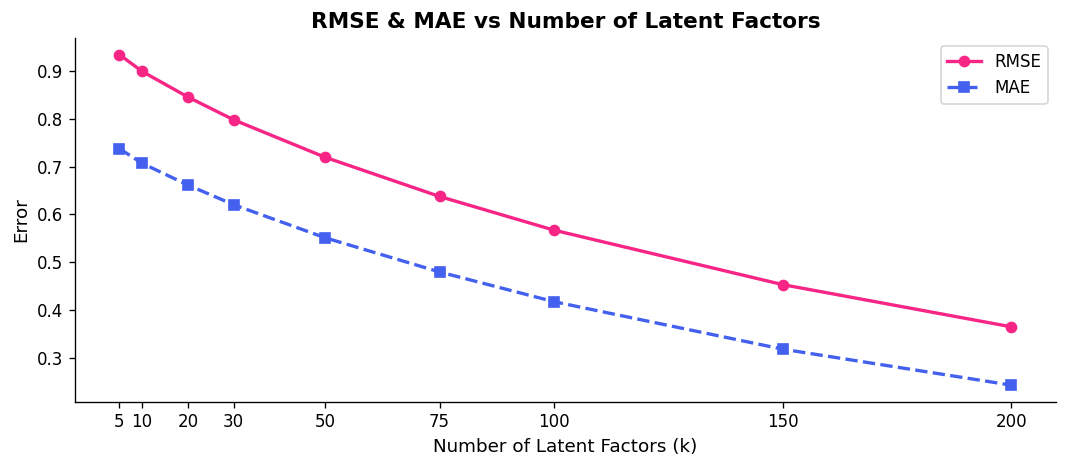

In [10]:
k_values = [5, 10, 20, 30, 50, 75, 100, 150, 200]
rmse_list, mae_list = [], []

for k in k_values:
    U_k, s_k, Vt_k = svds(R_demeaned, k=k)
    R_hat_k = np.dot(np.dot(U_k, np.diag(s_k)), Vt_k)
    R_hat_k = np.clip(R_hat_k + user_ratings_mean.reshape(-1,1), 1, 5)
    pred_df_k = pd.DataFrame(R_hat_k, index=user_ids, columns=item_ids)

    preds = test_df.apply(
        lambda r: pred_df_k.loc[r['user_id'], r['item_id']]
                  if r['user_id'] in pred_df_k.index and r['item_id'] in pred_df_k.columns
                  else np.nan,
        axis=1
    )
    mask = preds.notna()
    rmse_list.append(np.sqrt(mean_squared_error(test_df.loc[mask,'rating'], preds[mask])))
    mae_list.append(mean_absolute_error(test_df.loc[mask,'rating'], preds[mask]))
    print(f'k={k:>3d}  RMSE={rmse_list[-1]:.4f}  MAE={mae_list[-1]:.4f}')

# ── Plot error vs k ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_values, rmse_list, 'o-', color='#f72585', label='RMSE', lw=2)
ax.plot(k_values, mae_list,  's--', color='#4361ee', label='MAE',  lw=2)
ax.set_xlabel('Number of Latent Factors (k)', fontsize=11)
ax.set_ylabel('Error', fontsize=11)
ax.set_title('RMSE & MAE vs Number of Latent Factors', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mticker.FixedLocator(k_values))
plt.tight_layout()
plt.savefig('error_vs_k.png', bbox_inches='tight')
plt.show()

## Visualisation 1: Heatmap — Original vs Reconstructed Matrix

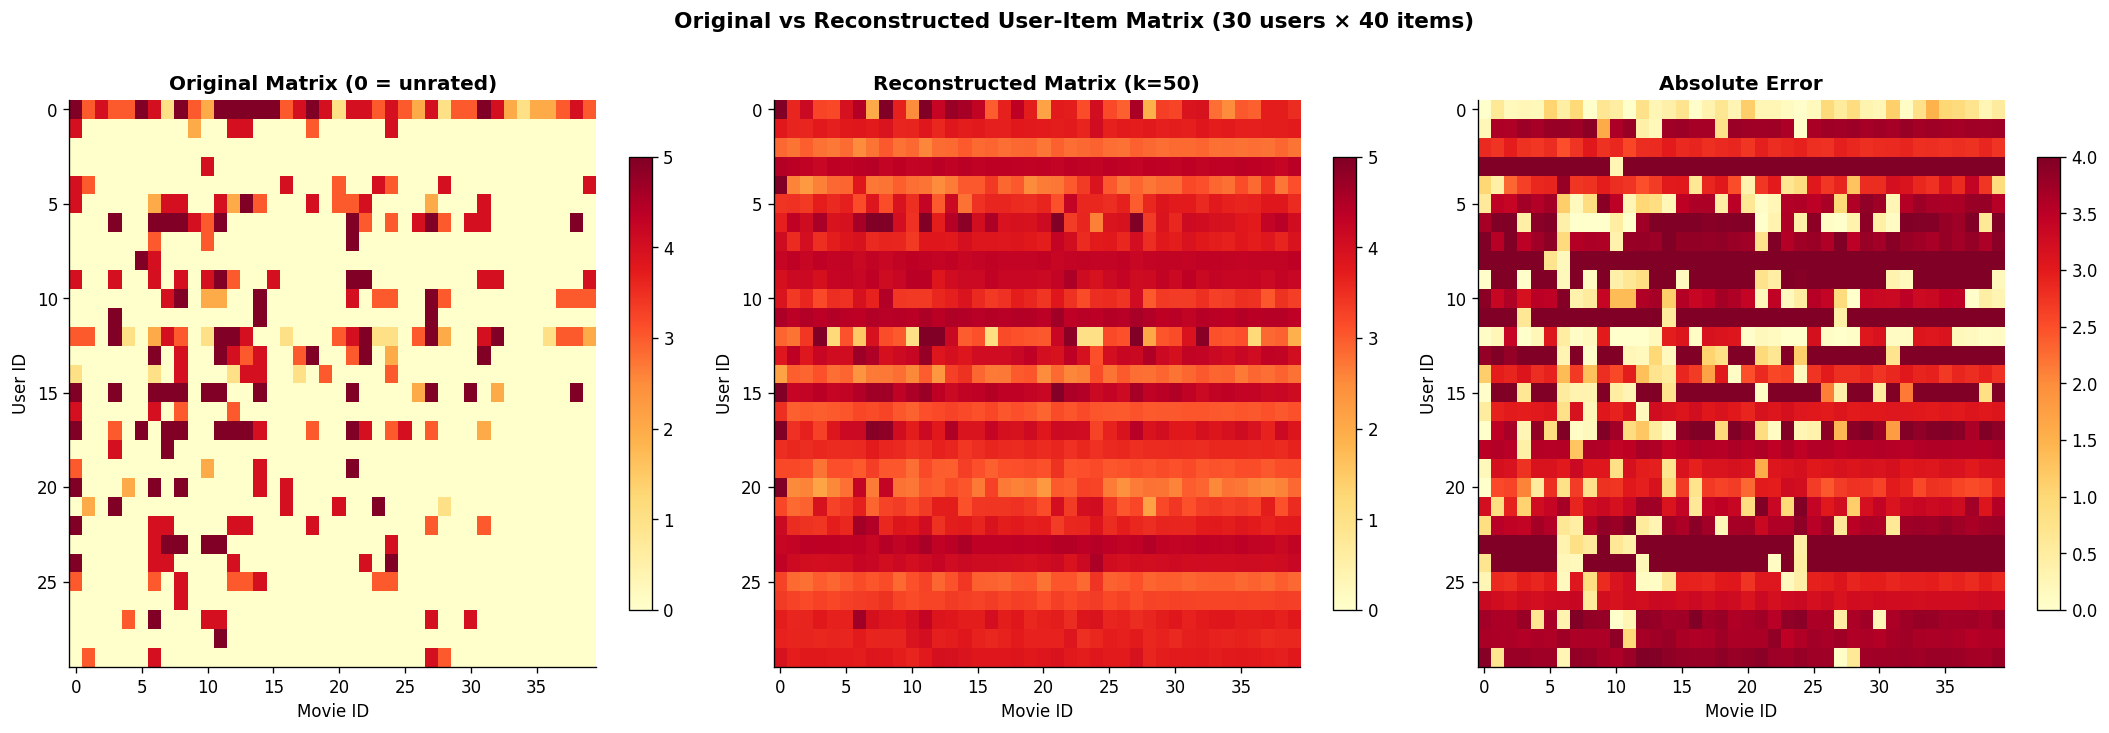

In [ ]:
# Show a 30×40 slice for readability
ROWS, COLS = 30, 40

R_orig_sub  = R[:ROWS, :COLS] 
R_hat_sub   = R_hat[:ROWS, :COLS]
R_error_sub = np.abs(R_orig_sub - R_hat_sub)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap = 'YlOrRd'

for ax, data, title in zip(
    axes,
    [R_orig_sub, R_hat_sub, R_error_sub],
    ['Original Matrix (0 = unrated)', f'Reconstructed Matrix (k={K})', 'Absolute Error']
):
    im = ax.imshow(data, aspect='auto', cmap=cmap,
                   vmin=0 if 'Error' not in title else 0,
                   vmax=5 if 'Error' not in title else 4)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Movie ID'); ax.set_ylabel('User ID')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Original vs Reconstructed User-Item Matrix (30 users × 40 items)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('heatmap_original_vs_reconstructed.png', bbox_inches='tight')
plt.show()

## Visualisation 2: Top Recommended Movies (Popularity Bar Chart)

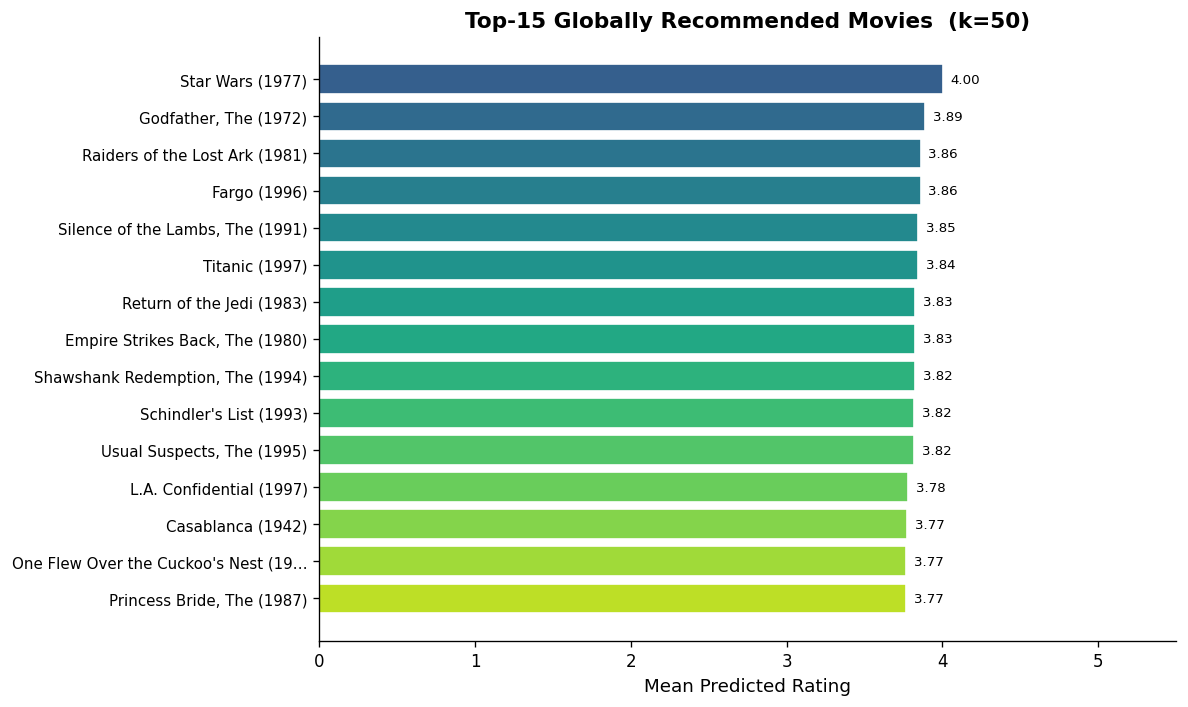

In [12]:
# Top-15 globally most recommended movies (highest mean predicted rating)
mean_pred = predictions_df.mean(axis=0).sort_values(ascending=False).head(15)

if HAS_TITLES:
    title_map = movies.set_index('item_id')['title']
    labels = mean_pred.index.map(title_map).fillna('Unknown')
    # Shorten long titles
    labels = [t[:35]+'…' if len(str(t))>35 else t for t in labels]
else:
    labels = [f'Movie_{iid}' for iid in mean_pred.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(mean_pred)))
bars = ax.barh(range(len(mean_pred)), mean_pred.values[::-1],
               color=colors[::-1], edgecolor='white')
ax.set_yticks(range(len(mean_pred)))
ax.set_yticklabels(labels[::-1], fontsize=9)
ax.set_xlabel('Mean Predicted Rating', fontsize=11)
ax.set_title(f'Top-15 Globally Recommended Movies  (k={K})', fontweight='bold', fontsize=13)
ax.set_xlim(0, 5.5)
for bar in bars:
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('top_recommended_movies.png', bbox_inches='tight')
plt.show()

## Bonus: Surprise SVD — Cross-Validated Evaluation

In [13]:
# Load data into Surprise format
reader  = Reader(rating_scale=(1, 5))
data_s  = Dataset.load_from_df(df[['user_id','item_id','rating']], reader)

# Train / test split (80/20)
trainset_s, testset_s = surprise_split(data_s, test_size=0.2, random_state=42)

# Fit Surprise SVD
svd_model = SVD(n_factors=50, n_epochs=20, random_state=42, verbose=False)
svd_model.fit(trainset_s)

# Evaluate
predictions_s = svd_model.test(testset_s)
print('── Surprise SVD Results ────────────────────')
print(f'RMSE : {accuracy.rmse(predictions_s, verbose=False):.4f}')
print(f'MAE  : {accuracy.mae(predictions_s,  verbose=False):.4f}')

# 5-fold cross-validation
cv_results = cross_validate(SVD(n_factors=50, random_state=42),
                            data_s, measures=['RMSE','MAE'], cv=5, verbose=False)
print(f'\n5-Fold CV  RMSE: {cv_results["test_rmse"].mean():.4f} ± {cv_results["test_rmse"].std():.4f}')
print(f'5-Fold CV  MAE : {cv_results["test_mae"].mean():.4f} ± {cv_results["test_mae"].std():.4f}')

── Surprise SVD Results ────────────────────
RMSE : 0.9348
MAE  : 0.7377

5-Fold CV  RMSE: 0.9331 ± 0.0022
5-Fold CV  MAE : 0.7356 ± 0.0016


## Summary

In [14]:
print('=' * 52)
print('         MovieLens SVD Recommender — Summary')
print('=' * 52)
print(f'  Dataset        : 100 K ratings, 943 users, 1682 items')
print(f'  Sparsity       : {sparsity*100:.2f}%')
print(f'  Best k (manual): tunable — check error_vs_k plot')
print(f'  Numpy SVD RMSE : {rmse:.4f}')
print(f'  Numpy SVD MAE  : {mae:.4f}')
print('=' * 52)
print()
print('Key observations:')
print('  • Low k  → underfitting (high bias)')
print('  • High k → overfitting (high variance)')
print('  • Optimal k balances bias-variance trade-off')
print('  • Mean-centering improves prediction accuracy')

         MovieLens SVD Recommender — Summary
  Dataset        : 100 K ratings, 943 users, 1682 items
  Sparsity       : 93.70%
  Best k (manual): tunable — check error_vs_k plot
  Numpy SVD RMSE : 0.7197
  Numpy SVD MAE  : 0.5511

Key observations:
  • Low k  → underfitting (high bias)
  • High k → overfitting (high variance)
  • Optimal k balances bias-variance trade-off
  • Mean-centering improves prediction accuracy
